# Model Comparison

Collects the results saved by the other notebooks (`results/*.csv`) and compares every model on the same test sets.
Run the model notebooks first: `EDA_FE_content_rec`, `clustering`, `collaborative_filtering`,
`neural_embedding_models`, `hybrid_recommenders` and `als_pyspark`.

1. **Baselines** that every model has to beat.
2. **Rating prediction (Part A):** test RMSE on the shared 80/20 rating split, on the 3 to 5 rating scale.
3. **Do the ratings carry signal?** Permutation tests for user and course effects.
4. **Enrolment prediction (Part B):** HitRate@10 and NDCG@10 on the shared leave-one-out split.
5. **Before and after:** the originally reported figures next to the corrected ones.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")
from recsys import data, evaluation, metrics, recommenders, results, splits

REPO = Path("..")
FAMILY_COLORS = {
    "Content-based": "#2a78d6",
    "Clustering": "#eb6834",
    "Collaborative filtering": "#1baf7a",
    "Hybrid": "#eda100",
    "Baseline": "#8a8a85",
}
INK = "#333333"
MUTED = "#8a8a85"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK})

## 1. Baselines

In [2]:
ratings = data.load_ratings()
index = data.Index(ratings)

train, test = splits.rating_split(ratings)
item_mean = test["item"].map(train.groupby("item")["rating"].mean()).fillna(train["rating"].mean())
baseline_rating_rows = [
    {"family": "Baseline", "model": "Global mean", "test_rmse": metrics.rmse(test["rating"], train["rating"].mean())},
    {"family": "Baseline", "model": "Course mean", "test_rmse": metrics.rmse(test["rating"], item_mean)},
]

train_loo, test_loo = splits.leave_one_out(ratings)
rng = np.random.default_rng(splits.SEED)
baseline_ranking_rows = [
    {"family": "Baseline", "model": "Random",
     **evaluation.evaluate_ranking(lambda m, u: rng.random((len(u), index.n_items)), train_loo, test_loo, index)},
    {"family": "Baseline", "model": "Most popular",
     **evaluation.evaluate_ranking(lambda m, u: recommenders.popularity_scores(m, len(u)), train_loo, test_loo, index)},
]

results.save(baseline_rating_rows, "rating_rmse", source="model_comparison")
results.save(baseline_ranking_rows, "ranking", source="model_comparison")
pd.DataFrame(baseline_rating_rows + baseline_ranking_rows).round(4)

,family,model,test_rmse,hit_rate@10,ndcg@10
0,Baseline,Global mean,0.8123,NaN,NaN
1,Baseline,Course mean,0.8128,NaN,NaN
2,Baseline,Random,NaN,0.0826,0.0378
3,Baseline,Most popular,NaN,0.5728,0.3408


## 2. Rating prediction (Part A)

In [3]:
rating = results.load("rating_rmse")
global_mean_rmse = rating.loc[rating["model"] == "Global mean", "test_rmse"].item()
rating["vs_global_mean"] = rating["test_rmse"] - global_mean_rmse
rating = rating.sort_values("test_rmse").reset_index(drop=True)
rating.round(4)

,family,model,test_rmse,source,vs_global_mean
0,Embedding regression,Lasso,0.8123,neural_embedding_models,0.0000
1,Embedding regression,ElasticNet,0.8123,neural_embedding_models,0.0000
2,Baseline,Global mean,0.8123,model_comparison,0.0000
3,Collaborative filtering,"ALS explicit, PySpark (rank 5, reg 0.5)",0.8124,als_pyspark,0.0001
4,Baseline,Course mean,0.8128,model_comparison,0.0005
5,Embedding regression,Linear Regression,0.8134,neural_embedding_models,0.0011
6,Embedding regression,Ridge,0.8134,neural_embedding_models,0.0011
7,Embedding regression,Gradient Boosting,0.8134,neural_embedding_models,0.0011
8,Embedding regression,Linear SVR,0.8134,neural_embedding_models,0.0011
9,Embedding regression,Random Forest,0.8135,neural_embedding_models,0.0012


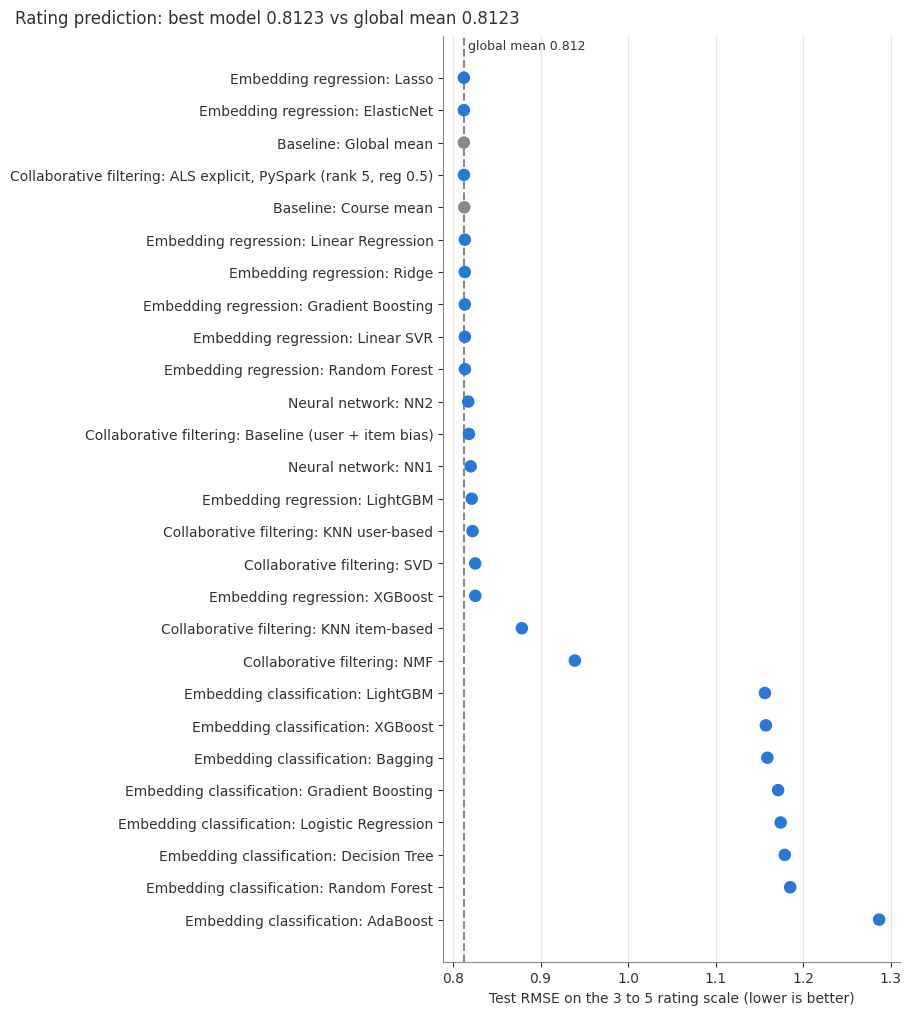

In [4]:
fig, ax = plt.subplots(figsize=(9, 0.32 * len(rating) + 1.4), layout="constrained")
labels = rating["family"] + ": " + rating["model"]
y = np.arange(len(rating))[::-1]
point_colors = np.where(rating["family"] == "Baseline", FAMILY_COLORS["Baseline"], FAMILY_COLORS["Content-based"])
ax.axvline(global_mean_rmse, color=MUTED, linestyle="--", linewidth=1.5)
ax.scatter(rating["test_rmse"], y, s=64, color=point_colors, zorder=3)
ax.set_yticks(y, labels)
ax.set_xlabel("Test RMSE on the 3 to 5 rating scale (lower is better)")
best_model = rating[rating["family"] != "Baseline"].iloc[0]
fig.suptitle(f"Rating prediction: best model {best_model['test_rmse']:.4f} vs global mean {global_mean_rmse:.4f}",
             x=0.01, ha="left", color=INK)
ax.text(global_mean_rmse, y.max() + 0.8, f" global mean {global_mean_rmse:.3f}", color=INK, va="bottom", fontsize=9)
ax.grid(axis="x", color="#e6e6e3")
fig.savefig(REPO / "rating_rmse.png", dpi=120)
plt.show()

Summary by model family (mean and best test RMSE):

In [5]:
rating.groupby("family")["test_rmse"].agg(models="count", mean="mean", best="min").sort_values("best").round(4)

,models,mean,best
family,,,
Baseline,2,0.8126,0.8123
Embedding regression,9,0.8154,0.8123
Collaborative filtering,6,0.8493,0.8124
Neural network,2,0.8187,0.8173
Embedding classification,8,1.1837,1.1563


## 3. Do the ratings carry signal?

If a user's ratings, or a course's ratings, were more alike than chance, grouping by user or course would explain more
variance than it does after randomly shuffling the ratings. The test statistic is the between-group sum of squares,
compared with 200 shuffles. Users with fewer than 5 ratings and courses with fewer than 20 are excluded so that small
groups do not dominate.

In [6]:
def between_group_ss(df, key):
    groups = df.groupby(key)["rating"].agg(["sum", "count"])
    return float((groups["sum"] ** 2 / groups["count"]).sum())


rng = np.random.default_rng(splits.SEED)
for key, min_count in [("user", 5), ("item", 20)]:
    subset = ratings[ratings.groupby(key)[key].transform("size") >= min_count].copy()
    observed = between_group_ss(subset, key)
    shuffled = []
    for _ in range(200):
        subset["rating"] = rng.permutation(subset["rating"].to_numpy())
        shuffled.append(between_group_ss(subset, key))
    shuffled = np.array(shuffled)
    z = (observed - shuffled.mean()) / shuffled.std()
    p = (shuffled >= observed).mean()
    print(f"{key} effect: {len(subset):,} ratings, z = {z:.2f}, permutation p = {p:.3f}")

user effect: 223,776 ratings, z = -0.88, permutation p = 0.815


item effect: 233,205 ratings, z = -0.14, permutation p = 0.535


Neither users nor courses explain any variance in the ratings beyond chance. The ratings behave like random draws from
{3, 4, 5}, independent of who rated which course, so no rating model can beat the global mean. The enrolments are a
different story: which courses a user takes is highly predictable, as Part B shows.

## 4. Enrolment prediction (Part B)
All models rank the same 126 courses for the same 25,581 test users, with one held-out enrolment per user.

In [7]:
ranking = results.load("ranking").sort_values("hit_rate@10", ascending=False).reset_index(drop=True)
ranking.round(4)

,family,model,hit_rate@10,ndcg@10,source
0,Hybrid,XGBoost ranker,0.7951,0.5654,hybrid_recommenders
1,Hybrid,LightGBM ranker,0.7906,0.5642,hybrid_recommenders
2,Collaborative filtering,User KNN (k=200),0.7856,0.5630,collaborative_filtering
3,Collaborative filtering,"ALS implicit, PySpark (rank 32, reg 1.0, alpha...",0.7734,0.5480,als_pyspark
4,Collaborative filtering,Item KNN (k=125),0.7379,0.5248,collaborative_filtering
5,Collaborative filtering,PureSVD (rank=4),0.6946,0.4712,collaborative_filtering
6,Clustering,HAC Ward-Euclidean,0.6735,0.4305,clustering
7,Clustering,KMeans,0.6662,0.4260,clustering
8,Clustering,KMeans on PCA,0.6653,0.4222,clustering
9,Clustering,HAC Complete-Cosine,0.6561,0.4087,clustering


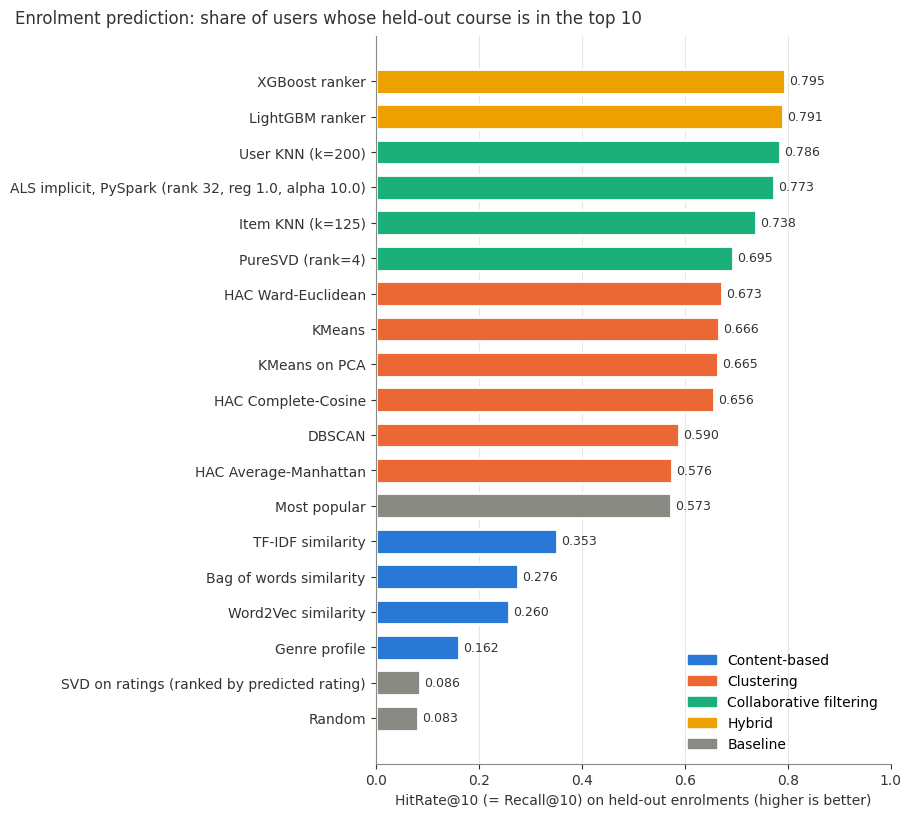

In [8]:
fig, ax = plt.subplots(figsize=(9, 0.34 * len(ranking) + 1.6), layout="constrained")
y = np.arange(len(ranking))[::-1]
colors = ranking["family"].map(FAMILY_COLORS)
ax.barh(y, ranking["hit_rate@10"], color=colors, height=0.7, edgecolor="white", linewidth=2)
for yi, value in zip(y, ranking["hit_rate@10"]):
    ax.text(value + 0.008, yi, f"{value:.3f}", va="center", color=INK, fontsize=9)
ax.set_yticks(y, ranking["model"])
ax.set_xlim(0, 1)
ax.set_xlabel("HitRate@10 (= Recall@10) on held-out enrolments (higher is better)")
fig.suptitle("Enrolment prediction: share of users whose held-out course is in the top 10", x=0.01, ha="left", color=INK)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
ax.legend(handles, FAMILY_COLORS.keys(), loc="lower right", frameon=False)
ax.grid(axis="x", color="#e6e6e3")
ax.set_axisbelow(True)
fig.savefig(REPO / "findings.png", dpi=120)
plt.show()

Summary by family. Means are across the models in each family, and the best column is the single best model.

In [9]:
by_family = ranking.groupby("family").agg(
    models=("model", "count"),
    mean_hit_rate=("hit_rate@10", "mean"),
    best_hit_rate=("hit_rate@10", "max"),
    best_ndcg=("ndcg@10", "max"),
)
by_family["best_model"] = ranking.loc[ranking.groupby("family")["hit_rate@10"].idxmax()].set_index("family")["model"]
by_family.sort_values("best_hit_rate", ascending=False).round(4)

,models,mean_hit_rate,best_hit_rate,best_ndcg,best_model
family,,,,,
Hybrid,2,0.7929,0.7951,0.5654,XGBoost ranker
Collaborative filtering,4,0.7479,0.7856,0.5630,User KNN (k=200)
Clustering,6,0.6378,0.6735,0.4305,HAC Ward-Euclidean
Baseline,3,0.2470,0.5728,0.3408,Most popular
Content-based,4,0.2624,0.3527,0.1782,TF-IDF similarity


## 5. Before and after

The originally reported figures are family means of test RMSE. They were not comparable across families: each family
used a different split, the neural network RMSE was computed on ratings rescaled to [0, 1], and the collaborative
filtering predictions were clipped to at most 3 by a wrong `rating_scale`. The corrected figures are family means on
the shared split and the 3 to 5 scale.

In [10]:
original = pd.DataFrame([
    ("Neural network", 0.4291, "RMSE on ratings rescaled to [0, 1], NN1 dot product bug"),
    ("Embedding regression", 0.8140, "Pre-computed embeddings of unknown origin, own split"),
    ("Embedding classification", 1.1607, "Own split"),
    ("Collaborative filtering", 1.2897, "rating_scale=(2, 3) clipped every prediction to 3, CV score not test score"),
], columns=["family", "original_mean_rmse", "original_issue"]).set_index("family")

corrected = rating[rating["family"] != "Baseline"].groupby("family")["test_rmse"].mean().rename("corrected_mean_rmse")
before_after = original.join(corrected)
before_after["global_mean_baseline"] = global_mean_rmse
before_after[["original_mean_rmse", "corrected_mean_rmse", "global_mean_baseline", "original_issue"]].round(4)

,original_mean_rmse,corrected_mean_rmse,global_mean_baseline,original_issue
family,,,,
Neural network,0.4291,0.8187,0.8123,"RMSE on ratings rescaled to [0, 1], NN1 dot pr..."
Embedding regression,0.8140,0.8154,0.8123,"Pre-computed embeddings of unknown origin, own..."
Embedding classification,1.1607,1.1837,0.8123,Own split
Collaborative filtering,1.2897,0.8493,0.8123,"rating_scale=(2, 3) clipped every prediction t..."


After correction every regression-type model (neural networks, embedding regressors, collaborative filtering) sits at
or above the global mean baseline, and the classifiers, which can only predict whole ratings, are well above it. The original ranking of
neural network over regression over collaborative filtering does not hold. The meaningful comparison is Part B.